## PMOS Prediction Using Clinical and Metabolical Indicators

## Dataset Description:

This dataset contains patient-level information related to Polyendocrine Metabolic Ovarian Syndrome (PMOS)  diagnosis. The data includes demographic, metabolic, hormonal, and clinical variables that may be associated with PMOS.

Variables included in the dataset:

- Age
- Body Mass Index (BMI)
- Menstrual Irregularity (0 = No, 1 = Yes)
- Testosterone Level (ng/dL)
- Antral Follicle Count (AFC)
- PCOS Diagnosis (0 = No, 1 = Yes)

The objective of this analysis is to investigate which variables contribute most to predicting PMOS diagnosis and to evaluate the performance of different logistic regression models.

## Project Objective:

The goal of this project is to build and evaluate predictive models for PMOS diagnosis using clinical and metabolic indicators. The analysis focuses on identifying the most influential predictors, comparing model performance under different feature selections, and understanding the characteristics of misclassified patients.

## 1. Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("../data/pcos_dataset.csv")
df.head()


,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [2]:
df.shape

(1000, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   BMI                        1000 non-null   float64
 2   Menstrual_Irregularity     1000 non-null   int64  
 3   Testosterone_Level(ng/dL)  1000 non-null   float64
 4   Antral_Follicle_Count      1000 non-null   int64  
 5   PCOS_Diagnosis             1000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 47.0 KB


In [4]:
df.describe()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.771000,26.38700,0.530000,60.159500,17.469000,0.199000
std,8.463462,4.93554,0.499349,23.160204,7.069301,0.399448
min,18.000000,18.10000,0.000000,20.000000,5.000000,0.000000
25%,24.000000,21.90000,0.000000,41.700000,12.000000,0.000000
50%,32.000000,26.40000,1.000000,60.000000,18.000000,0.000000
75%,39.000000,30.50000,1.000000,80.300000,23.250000,0.000000
max,45.000000,35.00000,1.000000,99.800000,29.000000,1.000000


In [5]:
df.columns

Index(['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)',
       'Antral_Follicle_Count', 'PCOS_Diagnosis'],
      dtype='object')

In [6]:
df['PCOS_Diagnosis'].value_counts()

PCOS_Diagnosis
0    801
1    199
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64

In [8]:
df.groupby('PCOS_Diagnosis').mean()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count
PCOS_Diagnosis,,,,,
0,32.043695,25.457928,0.413233,57.842447,16.792759
1,30.673367,30.126633,1.000000,69.485930,20.190955


## 2. Visualizations

In [9]:
import matplotlib.pyplot as plt

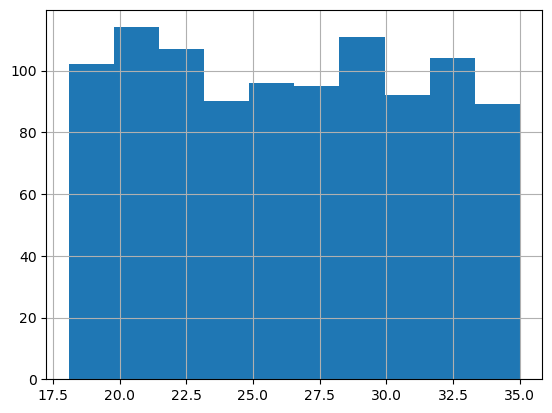

In [10]:
df['BMI'].hist()
plt.show()

BMI distribution is normal-looking, no extreme outliers.

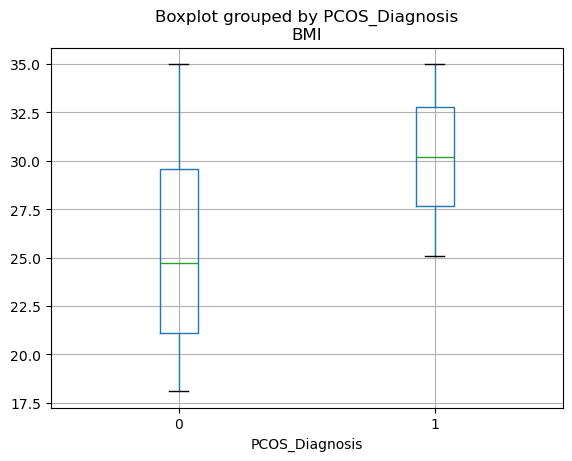

In [11]:
df.boxplot(column='BMI',by='PCOS_Diagnosis')
plt.show()

BMI is higher in PMOS patients (median is higher).
BMI differs (overlap, so not perfect predictor by itself)

## 3. Correlation Analysis

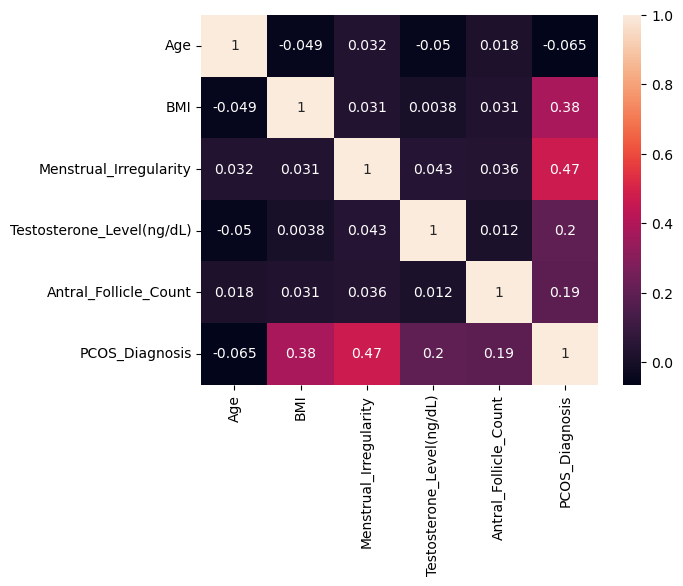

In [12]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

Correlations with PMOS Diagnosis:

- menstrual irregularity --> 0.47 strongest relationship. Most patients with irregular irregularity are more likely to have PMOS.
  
- BMI --> 0.38 still positive relationship. Higher BMI is associated with increased likelihood of PMOS diagnosis.

- Testosterone --> 0.20 weaker side but still positive relationship. Higher testosterone levels may be associated with PMOS but its weaker than BMI and menstrual irregularity.

- Antral Follicle Count --> 0.19 weaker side but still positive relationship. Higher follicle count may have some relationship with PMOS diagnosis.

- Age --> -0.065 weak negative relationship. Age is not strongly associated with PMOS diagnosis.

This shows that menstrual irregularity and BMI may be important predictors in PMOS models. 

In [13]:
from scipy import stats

Testing how BMI of PMOS patients and BMI of non PMOS patients compares:

In [14]:
pcos = df[df['PCOS_Diagnosis']==1]['BMI']
non_pcos = df[df['PCOS_Diagnosis']==0]['BMI']
stats.ttest_ind(pcos, non_pcos)

TtestResult(statistic=12.892557097334334, pvalue=2.7377182481000446e-35, df=998.0)

At 5% significance level p-value is smaller (extremely close to zero). It is statistically significant. BMI differences between PMOS and non-PMOS patients were statistically significant. 

Testing for Testosterone

In [15]:
pcos = df[df['PCOS_Diagnosis']== 1]['Testosterone_Level(ng/dL)']
non_pcos = df[df['PCOS_Diagnosis'] == 0]['Testosterone_Level(ng/dL)']
stats.ttest_ind(pcos, non_pcos)

TtestResult(statistic=6.475962400382639, pvalue=1.476003152874874e-10, df=998.0)

At 5% significance level p-value is smaller (extremely close to zero). It is statistically significant. Testosterone level differences between PMOS and non-PMOS patients were statistically significant.

Chi-square Test for Menstrual Irregularity

In [16]:
contingency_table = pd.crosstab(df['Menstrual_Irregularity'],df['PCOS_Diagnosis'])
stats.chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=217.96497995233292, pvalue=2.5135211020355294e-49, dof=1, expected_freq=array([[376.47,  93.53],
       [424.53, 105.47]]))

Once again at 5% p-value is smaller, very close to zero. So menstrual irregularity is significantly associated with PMOS diagnosis.

## 4. Logistic Regression

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


Importing tools from Pythons main machine learning library.

In [18]:
x = df[['BMI','Menstrual_Irregularity','Testosterone_Level(ng/dL)','Antral_Follicle_Count', 'Age']]
y = df['PCOS_Diagnosis']

defining features (x) --> information used to predict, and Target (y) --> what you're trying to predict. 
I am telling the model that here are the patients characteristics, learn pattern that will help identify PMOS. 

In [19]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.2, random_state= 42)

I am splitting the data, so train --> learn patterns, and test --> evaluate performance. 
test_size = 0.2 --> 20% testing and 80% training. 

In [20]:
model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


first creating an empty machine learning algorithm. (model = LogisticRegression())

then the model will study the (features(x)) and learn patterns that are associated with PMOS diagnosis. 

So the model is answering what combination of variables best predicts PMOS.

In [21]:
y_predic = model.predict(x_test)

Here the model is seeing new patients it has never seen before. By using x_test it predicts 0 or 1 for each patient. 
1 = PMOS
0 = Non PMOS

In [22]:
accuracy_score(y_test, y_predic)

0.885

Here I am comparing actual diagnosis vs model prediction. So the model is judged based on how many predictions were correct. 

The model correctly predicted PMOS diagnosis about 88.5% of the time on the test data. But why is the model performing that way? and which variables are contributing most? 

In [23]:
confusion_matrix(y_test, y_predic)

array([[151,  10],
       [ 13,  26]])

The logistic regression model correctly classified 151 non-PMOS patients and 26 PMOS patients. But the model produced 10 false positives and 13 false negatives. 

Although the results show that the model performs well, especially in identifying non-PMOS cases with an accuracy of 88.5% the presence of false negatives shows that some PMOS cases were missed, very important consideration in medical classification.  

Which is why we can look at the importance of the features (x):

In [24]:
pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_[0]})

,Feature,Coefficient
0,BMI,0.401234
1,Menstrual_Irregularity,5.470543
2,Testosterone_Level(ng/dL),0.056230
3,Antral_Follicle_Count,0.138161
4,Age,-0.009851


Each coefficient indicates --> direction of relationship and relative predictive influence.

So variables with larger positive coefficients are pushing prediction toward PMOS while variables with negative coefficients push prediction away from PMOS.

The model identified menstrual irregularity as the strongest predictor of PMOS diagnosis since it has a substantially larger positive coefficient compared to the other variables. BMI also has a meaningful positive relationship with PMOS prediction.

Testosterone level and AFC contributed smaller positive effects but age showed almost no predictive influence in the model. So these findings show that menstrual irregularity and BMI may be the most useful variables for diagnosing PMOS cases using this dataset. 

## 5. Feature Selection Experiments

## Model Experiment 1: Removing Age

The first logistic regression model showed that the age coefficient was close to zero which suggested little predictive contribution. Because of that I decided to do a second logistic regression model without age to evaluate whether age adds meaningful information or not. And with the results of this second model I can evaluate its performance.

In [25]:
x_no_age = df[['BMI','Menstrual_Irregularity','Testosterone_Level(ng/dL)','Antral_Follicle_Count']]
y = df['PCOS_Diagnosis']

Once again splitting data:

In [26]:
x_train_no_age, x_test_no_age, y_train, y_test = train_test_split(x_no_age, y, test_size = 0.2, random_state= 42)

In [27]:
model_no_age = LogisticRegression()
model_no_age.fit(x_train_no_age, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [28]:
y_pred_no_age = model_no_age.predict(x_test_no_age)

In [29]:
accuracy_score(y_test, y_pred_no_age)

0.885

In [30]:
confusion_matrix(y_test, y_pred_no_age)

array([[151,  10],
       [ 13,  26]])

In [31]:
pd.DataFrame({'Feature': x_no_age.columns, 'Coefficient': model_no_age.coef_[0]})

,Feature,Coefficient
0,BMI,0.402854
1,Menstrual_Irregularity,5.466053
2,Testosterone_Level(ng/dL),0.056681
3,Antral_Follicle_Count,0.138001


After taking a closer look the initial logistics regression model showed that the age coefficient was close to zero so it suggested very little contribution to PMOS diagnosis. 

To evaluate that I developed a second logistic regression model which was trained with BMI, menstrual irregularity, testosterone level and antral follicle count while excluding age. 

The result showed that the model achieved the same level of accuracy of 88.5% and had an identical confussion matrix compared to the initial model. And the coefficients remain unchanged as well. 

This suggests that age does not provide a meaningful predictive value for the diagnosis of PMOS using this dataset. So a simpler model excluding age can be used without sacrificing the predictive performance.

## Model Experiment 2: How well does Menstrual Irregularity predict PMOS by itself? 

I am training the same logistic regression model and comparing its accuracy, I chose to do it with menstrual irregularity because of its really big coefficient of 5.47 compared to the other variables. I think that menstrual irregularity alone may achieve high accuracy. 

In [32]:
x_menstrual = df[['Menstrual_Irregularity']]
y = df['PCOS_Diagnosis']

In [33]:
x_train_m, x_test_m, y_train, y_test = train_test_split(x_menstrual, y, test_size = 0.2, random_state = 42)

In [34]:
model_m = LogisticRegression()
model_m.fit(x_train_m, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
y_pred_m = model_m.predict(x_test_m)

In [36]:
accuracy_score(y_test, y_pred_m)

0.805

In [37]:
confusion_matrix(y_test, y_pred_m)

array([[161,   0],
       [ 39,   0]])

In [38]:
pd.DataFrame({'Feature': x_menstrual.columns, 'Coefficient': model_m.coef_[0]})

,Feature,Coefficient
0,Menstrual_Irregularity,3.96052


After looking at the results I concluded that although menstrual irregularity is the strongest predictor in the regression model it was not sufficient as a standalone predictor. When used alone, the model failed to identify any PMOS cases even after achieving an 80.5% accuracy (due to the class imbalance in the dataset (more non-pmos)). This shows that many clinical variables are needed to classify PMOS effectively. 

## Model Experiment 3: BMI and Menstrual Irregularity

Since we saw in the previous experiments BMI and menstrual irregularity, they are the strongest predictors of PMOS diagnosis. So I can evaluate if these two variables alone can achieve predictive performance that is similar to the initial model. 

In [39]:
x_bmi_menstrual = df[['BMI','Menstrual_Irregularity']]
y = df['PCOS_Diagnosis']

In [40]:
x_train_bm, x_test_bm, y_train, y_test = train_test_split(x_bmi_menstrual, y, test_size= 0.2, random_state= 42)

In [41]:
model_bm = LogisticRegression()
model_bm.fit(x_train_bm, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred_bm = model_bm.predict(x_test_bm)

In [43]:
accuracy_score(y_test, y_pred_bm)

0.845

In [44]:
confusion_matrix(y_test, y_pred_bm)

array([[146,  15],
       [ 16,  23]])

In [45]:
pd.DataFrame({'Feature': x_bmi_menstrual.columns, 'Coefficient': model_bm.coef_[0]})

,Feature,Coefficient
0,BMI,0.291578
1,Menstrual_Irregularity,4.399558


After these experiments I was able to find that age provided very low predictive value and by removing it the model's performance remained unchanged. Menstrual irregularity was the strongest individual predictor but when used alone the model failed to identify PMOS cases, by adding BMI it improved the classification performance by a lot. Increasing it to 84.5% and identifying 23 PMOS cases. The initial model has the highest performance of 88.5% which suggests that including testosterone and AFC is important because they provide additional but small predictive value to the model. 

## 6. Analysis of Misclassifications

In [46]:
results = x_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_predic
misclassified = results[results['Actual'] != results['Predicted']]
misclassified

,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,Age,Actual,Predicted
521,33.0,1,79.9,8,33,0,1
660,31.2,1,38.0,22,22,0,1
626,25.6,1,41.2,20,27,1,0
938,33.8,1,82.7,10,25,0,1
210,28.0,1,42.5,20,42,1,0
139,34.0,1,76.3,10,45,0,1
837,25.7,1,53.8,12,25,1,0
604,33.9,1,21.5,21,33,0,1
436,27.7,1,58.1,14,39,1,0
351,34.7,1,98.7,7,21,0,1


In [47]:
len(misclassified)

23

In [48]:
false_positives = results[(results['Actual'] == 0) & (results['Predicted'] == 1)]
false_positives

,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,Age,Actual,Predicted
521,33.0,1,79.9,8,33,0,1
660,31.2,1,38.0,22,22,0,1
938,33.8,1,82.7,10,25,0,1
139,34.0,1,76.3,10,45,0,1
604,33.9,1,21.5,21,33,0,1
351,34.7,1,98.7,7,21,0,1
892,24.9,1,78.8,29,38,0,1
425,29.8,1,88.3,7,20,0,1
445,32.7,1,36.9,28,40,0,1
208,34.1,1,35.7,24,40,0,1


In [49]:
false_negatives = results[(results['Actual'] == 1) & (results['Predicted'] == 0)]
false_negatives

,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,Age,Actual,Predicted
626,25.6,1,41.2,20,27,1,0
210,28.0,1,42.5,20,42,1,0
837,25.7,1,53.8,12,25,1,0
436,27.7,1,58.1,14,39,1,0
644,28.9,1,44.2,12,36,1,0
281,26.9,1,43.6,11,28,1,0
822,30.5,1,53.3,17,34,1,0
643,25.1,1,51.8,29,19,1,0
668,28.5,1,70.9,14,35,1,0
670,26.2,1,73.9,19,24,1,0


In [50]:
false_negatives.mean(numeric_only = True)

BMI                          27.584615
Menstrual_Irregularity        1.000000
Testosterone_Level(ng/dL)    54.192308
Antral_Follicle_Count        16.538462
Age                          32.076923
Actual                        1.000000
Predicted                     0.000000
dtype: float64

In [51]:
false_positives.mean(numeric_only = True)

BMI                          32.21
Menstrual_Irregularity        1.00
Testosterone_Level(ng/dL)    63.68
Antral_Follicle_Count        16.60
Age                          31.70
Actual                        0.00
Predicted                     1.00
dtype: float64

After doing the misclassification analysis I noticed that there where meaningful differences between false positives and false negatives. The false positive cases (predicted PMOS but not diagnosed) had an average BMI of 32.21, the false negative cases (diagnosed with PMOS but predicted as non-PMOS) had an average BMI of 27.58. This difference is 4.6 points suggesting that the model was more likely to miss PMOS patients who did not show the higher BMI levels that are commonly associated with the condition. 

Also, false positives showed a higher average testosterone level of 63.68 ng/dL compared to the false negatives 54.19 ng/dL. But since both BMI and testosterone has positive coefficients in the logistic regression model then patients with lower values for these variables were less likely to be classified as having PMOS even when they had a confirmed diagnosis. 

The most interesting insight was that both false positives and false negatives had an average menstrual irregularity of 1.00, which showed that menstrual irregularity alone was not able to distinguish difficult cases. So the model relied on the additional variables, especially BMI and testosterone to separate PMOS with non-PMOS patients. 

To conclude, these findings show that the model was more likely to miss PMOS cases when the patients showed less pronounced metabolic characteristics, like lower BMI and testosterone levels. 

## 7. Model Comparison

| Model | Features | Accuracy |
|-------|----------|----------|
| Full Model | BMI, Menstrual Irregualrity, Testosterone, AFC, Age | 88.5% |
| No Age | BMI, Menstrual Irregularity, Testosterone, AFC | 88.5% |
| Menstrual Only | Menstrual I rregularity | 80.5% |
| BMI + Menstrual | BMI, Menstrual Irregularity | 84.5% |

The full model had the highest performance of 88.5%. By removing age there was no effect on accuracy, showing that age did not provide a meaningful value. Menstrual irregularity alone had a high accuracy because of class imbalance but still failed to identify any PMOS cases. Adding BMI improved the classification performance, showing that BMI and menstrual irregularity together account for the majority of the predictive power in this dataset.

## 8. Conclusion
This project investigated which clinical and metabolic indicators are most useful for predicting PMOS diagnosis using logistic regression.

Menstrual irregularity emerged as the strongest predictor of PMOS, while BMI provided substantial additional predictive value. Testosterone level and antral follicle count contributed smaller improvements to model performance. Age demonstrated almost no predictive value, and removing it produced identical model results.

The full logistic regression model achieved an accuracy of 88.5% and correctly classified most patients. Feature selection experiments showed that BMI and menstrual irregularity together captured most of the predictive power in the dataset, while menstrual irregularity alone was insufficient to identify PMOS cases effectively.

Analysis of misclassified observations revealed that false negative PMOS cases tended to have lower BMI and testosterone levels than false positive cases. This suggests that the model performs best on patients exhibiting more typical PMOS characteristics and may struggle with less pronounced presentations.

A limitation of this study is the relatively small number of available variables. Additional clinical, hormonal, and metabolic measurements could potentially improve predictive performance and provide a more comprehensive understanding of PMOS diagnosis.


## Oficial rename from PCOS to PMOS 
(Polyendocrine Metabolic Ovarian Syndrome)

In [52]:
import os
print(os.getcwd())

/home/0e596d43-f997-4243-b0c7-d06449b300cb/pcos-metabolic-analysis/notebooks


In [53]:
os.listdir("..")


['notebooks', '.ipynb_checkpoints', 'data', 'READme.md']